# Ноутбук 1. EDA и отбор признаков

## Цели этапа

- Загрузить и изучить структуру всех исходных данных
- Проверить уникальность ключей и пересечения между таблицами
- Проанализировать целевую переменную `is_deal` (дисбаланс, распределение по клиентам)
- Выявить ключевые факторы, влияющие на конверсию (`variant_no`, `need_2ndfl`, `pil1mtrx_offer`)
- Проверить наличие data leakage (особенно для `pil1mtrx_offer`)
- Создать базовые matching-признаки (разница между запросом и предложением)
- Оценить возможность использования клиентских признаков из `features_small.pq`
- Сформулировать список признаков для дальнейшего моделирования


## 1. Импорт библиотек и настройки

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 200)

# Фиксация seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Загрузка исходных данных

В проекте используются три исходных файла:

| Файл | Размер | Ключевые колонки | Назначение |
|------|--------|------------------|-------------|
| `train_dataset_small.pq` | 845 110 × 23 | `app_id`, `offer_id`, `variant_no`, `is_deal` | Тренировочные данные (офферы + таргет) |
| `test_dataset_small.pq`  | 936 883 × 22 | `app_id`, `offer_id`, `variant_no` | Тестовые данные (без таргета) |
| `features_small.pq`      | 76 583 × 280 | `app_id`, много БКИ-признаков | Клиентские признаки (бюро кредитных историй) |

In [36]:
# Загрузка данных
train = pd.read_parquet('../data/train_dataset_small.pq')
test = pd.read_parquet('../data/test_dataset_small.pq')
features = pd.read_parquet('../data/features_small.pq')

print(f"train: {train.shape}")
print(f"test:  {test.shape}")
print(f"features: {features.shape}")

# Первые строки для ознакомления
print("\ntrain")
print(train.head(2))

print("\ntest")
print(test.head(2))

print("\nfeatures")
print(features.iloc[:, :10].head(2))

train: (845110, 23)
test:  (936883, 22)
features: (76583, 280)

train
         app_id           request_received   date_part                                        request_id  req_loan_amount  req_term verif_compl  offer_id  variant_no offer_type  pil1mtrx_offer  \
13  10027584851 2026-02-12 16:37:56.741739  2026-02-12  4854545000000000000de84d5211e16b0000000000005a94       30000000.0        60           N       472          32         RA               0   
16  10025438504 2026-01-17 19:06:42.950380  2026-01-17  48545450000000000000d8fbccb4f0c80000000000005a94       14000000.0        36           N       268           3         RA               0   

    is_deal                 rate  term       limit risk_level_map                     eva            eva_perc verif_need need_2ndfl                 ncl   channel basket_name  
13        0  36.9900000000000000    24  30000000.0             MR  31395.6889600000000000  0.0966780000000000          N          D  0.0545806700000000  Internet    

**Анализ:**

- **train:** 845 110 строк, 23 колонки — каждая строка соответствует одному кредитному предложению (офферу). Колонка `is_deal` — целевая переменная (1 — сделка, 0 — нет).
- **test:** 936 883 строки, 22 колонки — структура аналогична train, но без колонки `is_deal` (таргет нужно предсказать).
- **features:** 76 583 строки, 280 колонок — клиентские признаки, включая данные из бюро кредитных историй (префиксы `bki_`, `hdb_bki_`). Ключевая колонка для объединения — `app_id`.

**Первые наблюдения:**
- В `train` и `test` одинаковый набор колонок, кроме таргета.
- В `features` значительно больше колонок (280), чем описано в `feature_description.csv` (25). Многие из них, вероятно, получены из внешних источников (БКИ).
- В `features` много пропусков (`NaN`) — это будет учтено при анализе JOIN.

**Ключевые колонки для моделирования:**
- `app_id` — идентификатор заявки (группа для ранжирования)
- `offer_id` — идентификатор кредитного предложения
- `variant_no` — номер варианта (от 1 до 40)
- `is_deal` (только в train) — целевая переменная

**Дальнейшие шаги:** проверим уникальность ключей и пересечения между таблицами (следующий раздел).

## 3. Проверка уникальности ключей и пересечений

Перед объединением таблиц необходимо убедиться в корректности связей между ними.

In [37]:
train_apps = set(train['app_id'].unique())
test_apps = set(test['app_id'].unique())
features_apps = set(features['app_id'].unique())

print(f"Уникальных app_id в train: {len(train_apps):,}")
print(f"Уникальных app_id в test:  {len(test_apps):,}")
print(f"Уникальных app_id в features: {len(features_apps):,}")

print(f"\nПересечения")
print(f"  train и features: {len(train_apps & features_apps):,}")
print(f"  test и features:  {len(test_apps & features_apps):,}")
print(f"  train и test:     {len(train_apps & test_apps):,}")

dupl_mask = train.duplicated(subset=['app_id', 'offer_id'], keep=False)
n_duplicates = dupl_mask.sum()
print(f"\nДубликаты (app_id, offer_id) в train: {n_duplicates}")

Уникальных app_id в train: 37,817
Уникальных app_id в test:  38,694
Уникальных app_id в features: 76,435

Пересечения
  train и features: 37,817
  test и features:  38,694
  train и test:     76

Дубликаты (app_id, offer_id) в train: 1730



**Анализ:**

- Все 37 817 клиентов из train присутствуют в features. Теоретически возможно объединение.
- Все 38 694 клиентов из test также присутствуют в features.
- 76 клиентов входят одновременно в train и test. Это исключает использование простого случайного разбиения; необходима валидация через GroupKFold.
- В train обнаружены дубликаты по паре (app_id, offer_id). Всего таких строк 1 730 (865 уникальных пар). При обучении дубликаты будут удалены (оставлена первая запись).



## 4. Структура ранжирования (группы)



In [38]:
offers_per_app_train = train.groupby('app_id').size()
offers_per_app_test = test.groupby('app_id').size()

print(f"в трейн предложения на app_id")
print(f"  Среднее: {offers_per_app_train.mean():.2f}")
print(f"  Медиана: {offers_per_app_train.median():.0f}")
print(f"  Минимум: {offers_per_app_train.min()}")
print(f"  Максимум: {offers_per_app_train.max()}")
print(f"  Стандартное отклонение: {offers_per_app_train.std():.2f}")

print(f"\nв трейн предложения на app_id")
print(f"  Среднее: {offers_per_app_test.mean():.2f}")
print(f"  Медиана: {offers_per_app_test.median():.0f}")
print(f"  Минимум: {offers_per_app_test.min()}")
print(f"  Максимум: {offers_per_app_test.max()}")
print(f"  Стандартное отклонение: {offers_per_app_test.std():.2f}")

в трейн предложения на app_id
  Среднее: 22.35
  Медиана: 23
  Минимум: 1
  Максимум: 100
  Стандартное отклонение: 12.32

в трейн предложения на app_id
  Среднее: 24.21
  Медиана: 25
  Минимум: 1
  Максимум: 100
  Стандартное отклонение: 12.21



- В train в среднем 22.3 оффера на клиента, в test — 24.2. Разница связана с составом выборок.
- У всех клиентов есть хотя бы одно предложение. Минимальный размер группы — 1, максимальный — 100.
- Стандартное отклонение около 12, что подтверждает значительный разброс в количестве предложений на клиента.

**Значение для моделирования:** app_id будет использоваться как идентификатор группы (qid/group) в ранжирующих алгоритмах (LGBMRanker, XGBRanker, CatBoostRanker). Валидация должна проводиться с учётом групповой структуры (GroupKFold), чтобы не разрывать офферы одного клиента между train и val.

## 5. Анализ целевой переменной is_deal

In [39]:
deal_counts = train['is_deal'].value_counts()
deal_pct = train['is_deal'].value_counts(normalize=True) * 100

print(f"Распределение is_deal:")
print(f"  Сделка (1): {deal_counts.get(1, 0):,} строк ({deal_pct.get(1, 0):.2f}%)")
print(f"  Нет сделки (0): {deal_counts.get(0, 0):,} строк ({deal_pct.get(0, 0):.2f}%)")

# На уровне клиента
deals_per_client = train.groupby('app_id')['is_deal'].sum()
print(f"\nРаспределение сделок на клиента")
print(f"  0 сделок {(deals_per_client == 0).sum()}")
print(f"  1 сделка  {(deals_per_client == 1).sum()}")
print(f"  2 и болеее сделок {(deals_per_client >= 2).sum()}")

if (deals_per_client >= 2).sum() > 0:
    print(f"\n  Максимум сделок у одного клиента {deals_per_client.max()}")

Распределение is_deal:
  Сделка (1): 37,891 строк (4.48%)
  Нет сделки (0): 807,219 строк (95.52%)

Распределение сделок на клиента
  0 сделок 0
  1 сделка  37743
  2 и болеее сделок 74

  Максимум сделок у одного клиента 2



- Доля сделок составляет 4.48% (37 891 строка из 845 110). Наблюдается сильный дисбаланс классов: положительный класс (сделка) встречается значительно реже отрицательного.
- На уровне клиентов: 99.8% клиентов (37 743 из 37 817) имеют ровно одну сделку. Лишь 74 клиента (0.2%) совершили две сделки, и ни одного клиента с тремя и более сделками.
- Все клиенты в тренировочной выборке совершили хотя бы одну сделку. Это означает, что в валидационной выборке не будет клиентов без положительного примера.

**Значение для моделирования:**
- Дисбаланс классов необходимо учитывать при выборе метрики. NDCG@5 (метрика качества ранжирования) менее чувствительна к дисбалансу, чем accuracy или logloss, что делает её подходящей для данной задачи.
- Валидация должна проводиться строго через GroupKFold, так как строки одного клиента (офферы) нельзя разрывать между обучающей и валидационной выборками.
- Наличие у всех клиентов хотя бы одной сделки упрощает оценку качества ранжирования: для каждого клиента есть хотя бы один релевантный оффер, который модель должна поставить на верхние позиции.

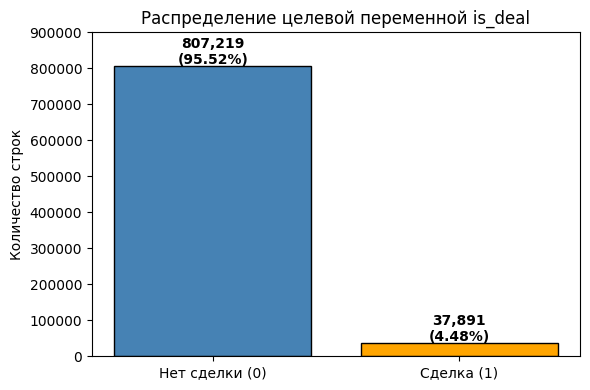

In [40]:
# Вставляем после раздела 5 (анализ is_deal)
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['steelblue', 'orange']
bars = ax.bar(['Нет сделки (0)', 'Сделка (1)'], 
              [deal_counts.get(0, 0), deal_counts.get(1, 0)], 
              color=colors, edgecolor='black')
ax.set_ylabel('Количество строк')
ax.set_title('Распределение целевой переменной is_deal')
ax.set_ylim(0, 900000) 
for bar, count, pct in zip(bars, 
                           [deal_counts.get(0, 0), deal_counts.get(1, 0)],
                           [deal_pct.get(0, 0), deal_pct.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
            f'{count:,}\n({pct:.2f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Анализ variant_no (номер варианта кредитного предложения)

In [41]:
variant_stats = train.groupby('variant_no').agg(
    total=('is_deal', 'count'),
    deals=('is_deal', 'sum'),
    conversion=('is_deal', 'mean')
).sort_values('conversion', ascending=False)

print("Топ 10 вариантов по конверсии:")
print(variant_stats.head(10)[['total', 'deals', 'conversion']])

print("\nХудшие 10 вариантов по конверсии:")
print(variant_stats.tail(10)[['total', 'deals', 'conversion']])

Топ 10 вариантов по конверсии:
            total  deals  conversion
variant_no                          
1           37891   9108    0.240374
3           36149   4023    0.111289
4           35285   3124    0.088536
5           34482   3012    0.087350
2           37188   3046    0.081908
6           33846   2268    0.067009
7           33145   2006    0.060522
8           32403   1487    0.045891
9           31577   1271    0.040251
11          29956   1154    0.038523

Худшие 10 вариантов по конверсии:
            total  deals  conversion
variant_no                          
41           1893      4    0.002113
33           8257     16    0.001938
37           4897      9    0.001838
35           6554     12    0.001831
50           1278      2    0.001565
49           1317      2    0.001519
48           1354      2    0.001477
34           7515     10    0.001331
38           4160      4    0.000962
40           2584      2    0.000774


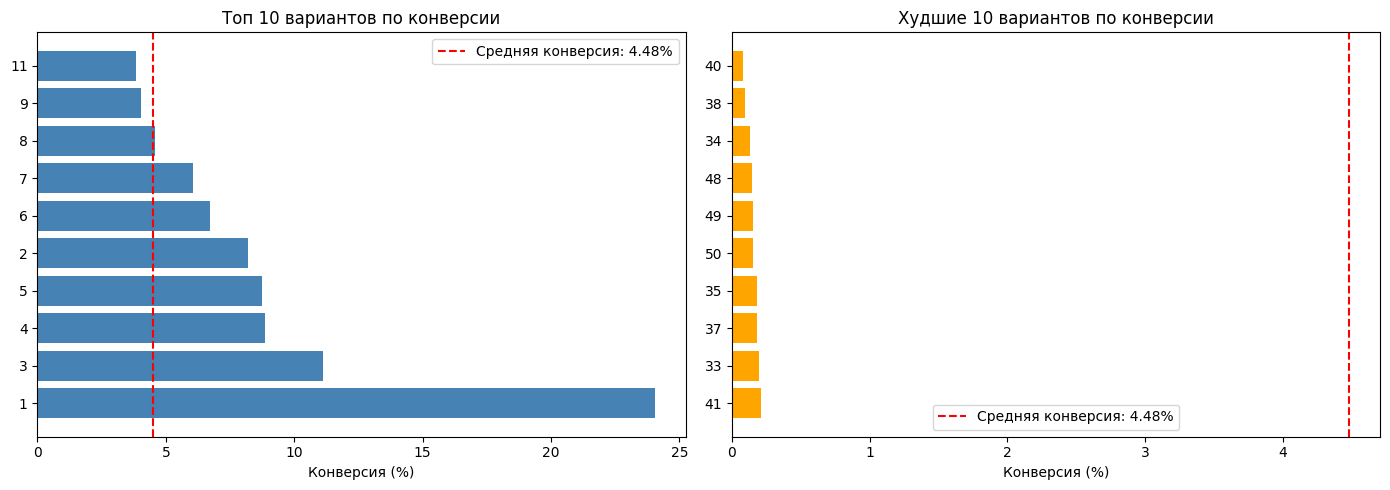

In [42]:
# График
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10 = variant_stats.head(10)
axes[0].barh(top10.index.astype(str), top10['conversion'] * 100, color='steelblue')
axes[0].axvline(deal_pct.get(1, 0), color='red', linestyle='--', 
                label=f'Средняя конверсия: {deal_pct.get(1, 0):.2f}%')
axes[0].set_xlabel('Конверсия (%)')
axes[0].set_title('Топ 10 вариантов по конверсии')
axes[0].legend()

bottom10 = variant_stats.tail(10)
axes[1].barh(bottom10.index.astype(str), bottom10['conversion'] * 100, color='orange')
axes[1].axvline(deal_pct.get(1, 0), color='red', linestyle='--', 
                label=f'Средняя конверсия: {deal_pct.get(1, 0):.2f}%')
axes[1].set_xlabel('Конверсия (%)')
axes[1].set_title('Худшие 10 вариантов по конверсии')
axes[1].legend()

plt.tight_layout()
plt.show()

- **variant_no=1** занимает особое место: конверсия 24.0%, что в 5.4 раза выше среднего (4.48%). Этот вариант присутствует у каждого клиента ровно один раз. Вероятно, это предодобренное (pre-approved) предложение с максимально доступными условиями без необходимости подтверждения дохода.
- **Топ-5 вариантов** (1, 3, 4, 5, 2) стабильно показывают конверсию выше 8%. Они составляют основную массу сделок.
- **Худшие варианты** (34, 38, 40) имеют конверсию менее 0.2%. Практически никто не берёт кредиты с такими параметрами.
- Разброс конверсии между лучшим и худшим вариантом — в 300 раз.

**Значение для моделирования:**
- `variant_no` является критически важным категориальным признаком.
- Модель должна учитывать, что вариант 1 ведёт себя иначе, чем все остальные.
- Можно дополнительно создать бинарный признак `is_variant_1`.

## 7. Анализ basket_name (бизнес-правила)

basket_name содержит список правил, по которым оффер был сформирован. Из него можно извлечь полезные признаки.

In [43]:
# Просмотр всречающихся значиний
print("Уникальные значения basket_name:")
print(train['basket_name'].dropna().unique()[:20])

# Примеры предложений со сделками и без
print("\nПримеры basket_name для сделок (is_deal=1):")
print(train[train['is_deal'] == 1]['basket_name'].dropna().head(3).tolist())

print("\nПримеры basket_name для отказов (is_deal=0):")
print(train[train['is_deal'] == 0]['basket_name'].dropna().head(3).tolist())

Уникальные значения basket_name:
['noverifdocmaxlimit' 'maxlimit, minannuity, noverifdocmaxlimit'
 'desiredparams' 'maxlimit, noverifdocmaxlimit'
 'desiredparams, minannuity' 'minannuity'
 'desiredparams, maxlimit, minannuity, noverifdocmaxlimit'
 'desiredparams, maxlimit, noverifdocmaxlimit'
 'desiredparams, maxlimit, minannuity' 'maxlimit'
 'desiredparams, maxlimit' 'maxlimit, minannuity']

Примеры basket_name для сделок (is_deal=1):
['maxlimit, minannuity, noverifdocmaxlimit', 'noverifdocmaxlimit', 'desiredparams']

Примеры basket_name для отказов (is_deal=0):
['noverifdocmaxlimit', 'noverifdocmaxlimit', 'noverifdocmaxlimit']


- basket_name содержит перечень бизнес-правил, разделённых запятыми. Уникальных комбинаций — 12.
- В сделках (is_deal=1) чаще встречаются комбинации с `maxlimit` и `minannuity`.
- В отказах (is_deal=0) преобладает правило `noverifdocmaxlimit` (без верификации документов).

**Значение для моделирования:**
- Из basket_name можно извлечь бинарные признаки:
  - `has_desiredparams`
  - `has_minannuity`
  - `has_maxlimit`
  - `has_noverifdocmaxlimit`
- Также можно посчитать количество правил в оффере (`basket_rules_count`).

Эти признаки будут созданы на этапе feature engineering.

## 9. Проверка data leakage для pil1mtrx_offer

pil1mtrx_offer — флаг вторичного процесса продаж. Важно проверить, не проставляется ли он после совершения сделки.

In [44]:
# Таблица сопряжённости
pil_crosstab = pd.crosstab(train['pil1mtrx_offer'], train['is_deal'], margins=True, normalize='columns')
print("Доля офферов с pil1mtrx_offer=1 среди сделок и отказов")
print(pil_crosstab.round(4))

# Абсолютные значения
pil_abs = pd.crosstab(train['pil1mtrx_offer'], train['is_deal'], margins=True)
print("\nАбсолютные значения")
print(pil_abs)

Доля офферов с pil1mtrx_offer=1 среди сделок и отказов
is_deal              0       1     All
pil1mtrx_offer                        
0               0.9999  0.3356  0.9701
1               0.0001  0.6644  0.0299

Абсолютные значения
is_deal              0      1     All
pil1mtrx_offer                       
0               807152  12717  819869
1                   67  25174   25241
All             807219  37891  845110


In [45]:
# проверка pil1mtrx_offer в тесте 
print("pil1mtrx_offer в трейне")

print(f"  Уникальные значения: {train['pil1mtrx_offer'].unique()}")
print(f"  Распределение:")
print(train['pil1mtrx_offer'].value_counts())
print(f"  Доля = 1: {train['pil1mtrx_offer'].mean():.4f} ({train['pil1mtrx_offer'].mean()*100:.2f}%)")

print("pil1mtrx_offer в тесте")
print(f"  Уникальные значения: {test['pil1mtrx_offer'].unique()}")
print(f"  Распределение:")
print(test['pil1mtrx_offer'].value_counts())
print(f"  Доля = 1: {test['pil1mtrx_offer'].mean():.4f} ({test['pil1mtrx_offer'].mean()*100:.2f}%)")

# Проверка связь с is_deal в трейне
print("Связб с таргетом")
print(pd.crosstab(train['pil1mtrx_offer'], train['is_deal'], 
                   rownames=['pil'], colnames=['is_deal'], margins=True))

pil1mtrx_offer в трейне
  Уникальные значения: [0 1]
  Распределение:
pil1mtrx_offer
0    819869
1     25241
Name: count, dtype: int64
  Доля = 1: 0.0299 (2.99%)
pil1mtrx_offer в тесте
  Уникальные значения: [0 1]
  Распределение:
pil1mtrx_offer
0    911544
1     25339
Name: count, dtype: int64
  Доля = 1: 0.0270 (2.70%)
Связб с таргетом
is_deal       0      1     All
pil                           
0        807152  12717  819869
1            67  25174   25241
All      807219  37891  845110


### Результаты проверки

**В тренировочных данных:**

| is_deal | pil1mtrx_offer=0 | pil1mtrx_offer=1 | Всего |
|---------|------------------|------------------|-------|
| 0 (отказ) | 807 152 (99.99%) | 67 (0.01%) | 807 219 |
| 1 (сделка) | 12 717 (33.56%) | 25 174 (66.44%) | 37 891 |
| **Всего** | 819 869 | 25 241 | 845 110 |

**В тестовых данных:**

| Показатель | Train | Test |
|------------|-------|------|
| Доля pil1mtrx_offer=1 | 2.99% | 2.70% |

### Наблюдения и анализ:

1. **Признак присутствует в тестовой выборке** (2.70% против 2.99% в тренировочной) — 
   распределения практически идентичны. Если бы флаг проставлялся после совершения 
   сделки и был недоступен в момент предсказания, он либо отсутствовал бы в тесте, 
   либо имел принципиально иное распределение.

2. **Треть сделок (33.6%) не содержат данный флаг** — если бы признак определялся 
   фактом совершения сделки, он был бы равен единице у 100% строк с `is_deal=1`. 
   Наличие значительной доли сделок без флага опровергает гипотезу о data leakage.

3. **Высокая корреляция с целевой переменной содержательно интерпретируема:** 
   вторичные продажи — это предложения, формируемые при повторном взаимодействии 
   банка с клиентом (например, после звонка оператора). Такие клиенты конвертируются 
   значительно лучше (66.4% против 4.5% в среднем), однако сам факт отнесения оффера 
   к категории вторичных продаж известен до момента предсказания.

### Вывод

Признак `pil1mtrx_offer` **не является data leakage** и включается в финальную модель 
(32 признака).

## 10. Matching features (признаки согласования оффера с запросом клиента)

На данном этапе необходимо создать признаки, показывающие, насколько предложение отличается от того, что запросил клиент.

In [46]:
# Создание matching features
train['diff_amount'] = train['limit'] - train['req_loan_amount']
train['diff_term'] = train['term'] - train['req_term']
train['abs_diff_amount'] = np.abs(train['diff_amount'])
train['abs_diff_term'] = np.abs(train['diff_term'])
train['ratio_amount'] = train['limit'] / (train['req_loan_amount'].replace(0, np.nan)).fillna(1)
train['ratio_term'] = train['term'] / (train['req_term'].replace(0, np.nan)).fillna(1)

# Распределение для сделок и отказов
print("matching features для сделок и отказов")
compare = train.groupby('is_deal')[['abs_diff_amount', 'abs_diff_term', 'ratio_amount', 'ratio_term']].mean()
print(compare.round(2))

matching features для сделок и отказов
         abs_diff_amount  abs_diff_term  ratio_amount  ratio_term
is_deal                                                          
0             27725698.0          23.16          0.82        0.82
1             16895722.0           9.50          0.89        0.97



- **abs_diff_amount**: среднее отклонение по сумме для сделок (16.9 млн) значительно меньше, чем для отказов (27.7 млн). Клиенты чаще берут кредит, когда предложенная сумма близка к запрошенной.
- **abs_diff_term**: аналогичная картина по сроку: для сделок отклонение 9.5 месяцев, для отказов — 23.2 месяца.
- **ratio_amount**: отношение предложенной суммы к запрошенной. У сделок значение ближе к 1 (0.89), у отказов — 0.82.
- **ratio_term**: отношение предложенного срока к запрошенному. У сделок 0.97, у отказов 0.82.

**Вывод** -  чем ближе предложение к запросу клиента по сумме и сроку, тем выше вероятность сделки. Matching features будут включены в набор признаков.

## 11. Анализ channel (канал заявки) и verif_compl (верификация)

In [47]:
# Анализ channel
channel_stats = train.groupby('channel')['is_deal'].agg(['count', 'mean'])
channel_stats.columns = ['total', 'conversion']
print("Конверсия по каналам")
print(channel_stats)

# Анализ verif_compl
verif_stats = train.groupby('verif_compl')['is_deal'].agg(['count', 'mean'])
verif_stats.columns = ['total', 'conversion']
print("\nКонверсия по verif_compl")
print(verif_stats)

# Комбинация channel × verif_compl
combo_stats = train.groupby(['channel', 'verif_compl'])['is_deal'].agg(['count', 'mean'])
combo_stats.columns = ['total', 'conversion']
print("\nКонверсия по комбинации channel × verif_compl")
print(combo_stats)

Конверсия по каналам
           total  conversion
channel                     
Front     176525    0.038595
Internet  668585    0.046483

Конверсия по verif_compl
              total  conversion
verif_compl                    
N            835864    0.044828
Y              9246    0.045533

Конверсия по комбинации channel × verif_compl
                       total  conversion
channel  verif_compl                    
Front    N            172461    0.038478
         Y              4064    0.043553
Internet N            663403    0.046479
         Y              5182    0.047086



- **channel**: интернет-канал (Internet) имеет конверсию 4.65%, фронт-канал (Front) — 3.86%. Разница составляет 0.79 п.п. При этом доля интернет-канала — 79% всех заявок.
- **verif_compl**: верификация, пройденная ранее (Y), даёт конверсию 4.55%, без верификации (N) — 4.48%. Разница минимальна (0.07 п.п.), признак слабый.
- **Комбинация channel × verif_compl**: наивысшая конверсия у интернет-канала с пройденной верификацией (4.71%), наинизшая — у фронт-канала без верификации (3.85%).

**Значение для моделирования:**
- channel будет закодирован в бинарный признак (Internet=0, Front=1)
- verif_compl также будет закодирован в бинарный признак (N=0, Y=1)

## 12. Анализ features_small.pq (клиентские признаки)

При попытке объединить тренировочные данные с клиентскими признаками из features_small.pq выяснилось следующее:

In [48]:
train_apps = train['app_id'].nunique()
features_apps = features['app_id'].nunique()
intersection = len(set(train['app_id']) & set(features['app_id']))

print(f"Уникальных app_id в train {train_apps:,}")
print(f"Уникальных app_id в features {features_apps:,}")
print(f"Пересечение train и features {intersection:,}")


common_cols = set(train.columns) & set(features.columns) - {'app_id'}
features_join = features.drop(columns=list(common_cols), errors='ignore')
train_merged = train.merge(features_join, on='app_id', how='left')


first_feature_col = [c for c in features_join.columns if c != 'app_id'][0]
missing_pct = train_merged[first_feature_col].isnull().mean() * 100

print(f"\nДоля пропусков в клиентских признаках при объединении {missing_pct:.1f}%")

Уникальных app_id в train 37,817
Уникальных app_id в features 76,435
Пересечение train и features 37,817

Доля пропусков в клиентских признаках при объединении 82.0%


**Анализ:**

- В features содержится 76 435 уникальных app_id.
- В train — 37 817 уникальных app_id.
- Все app_id из train присутствуют в features (пересечение 100%).
- Однако при объединении на уровне строк (офферов) доля пропусков в клиентских признаках составила **82%**.

**Причина:** features содержит данные только для части записей (76 435 строк против 845 110 строк в train). Клиентские признаки доступны лишь для небольшой доли офферов.

**Вывод:** использование features_small.pq в модели невозможно из-за слишком высокого процента пропусков. В финальный пайплайн эти признаки не включаются.

## 13. Выводы EDA и план Feature Engineering

### Ключевые выводы

**Структура данных:**
- 37 817 клиентов, в среднем 22 оффера на заявку. Ранжирование внутри группы `app_id`.
- Дисбаланс целевой переменной: 4.48% положительных исходов. У 99.8% клиентов ровно одна сделка.
- 76 клиентов присутствуют одновременно в train и test — валидация строго через GroupKFold по `app_id`.

**Проверка на data leakage:**
- `pil1mtrx_offer` присутствует в тестовой выборке с тем же распределением (2.70% против 2.99% в трейне), треть сделок не содержит флаг. Признак признан безопасным и оставлен в модели.

**Клиентские признаки из features_small.pq:**
- 280 признаков, все `app_id` из train присутствуют в features.
- При JOIN на уровне строк — 82% пропусков. Принято решение не включать в итоговую модель.

### Признаки для моделирования

| Группа | Кол-во | Примеры |
|--------|--------|---------|
| Параметры оффера | 9 | variant_no, rate, term, limit, ncl, eva_perc |
| Бюрократия и канал | 7 | verif_need, need_2ndfl, verif_compl, channel, pil1mtrx, req_loan_amount, req_term |
| Matching (оффер vs запрос) | 6 | diff_amount, abs_diff_term, ratio_term |
| Basket (бизнес-правила) | 5 | has_desiredparams, has_minannuity, basket_rules_count |
| Комбинированные | 5 | rate/ncl, limit/term, term×rate |
| **Итого** | **32** | |

### План второго ноутбука (создание признаков и обучение)

1. Загрузка данных, удаление дубликатов, конвертация Decimal → float
2. Кодирование категориальных признаков
3. Создание matching-признаков и признаков из basket_name
4. Создание комбинированных признаков
5. Обучение LGBMRanker (lambdarank) с валидацией GroupKFold
6. Ансамбль трёх моделей с разными seed, взвешенное усреднение
7. Формирование `answers.csv`